In [1]:
from define_system import *
from steady_state_KF import *
from simulate import *
from dataloader import *
from ARmodel import *
from train_test import *

import matplotlib.pyplot as plt

In [2]:
n, p, m = 4, 2, 3
rho_target=1.0
sys_seed = 0

A, B, C = define_system(n, p, m, rho_target, seed=sys_seed)
W = 0.05 * np.eye(n)
V = 0.1 * np.eye(m)

Spectral radius of A:  1.0000000000000007
Observable? True (rank 4 of 4)
Controllable? True (rank 4 of 4)


In [3]:
model, kf_states, act_states, _ = train_test(
    A=A,
    B=B,
    C=C,
    W=W,
    V=V,
    L=10,
    H=5,
    T=10000,
    testT=1000,
    epochs=150,
    batch_size=64,
    lr=0.05,
    step_size=2,
    gamma=0.9,
    lambda_reg=1e-3,
    train_seed=10,
    torch_seed=20,
    test_seed=30,
    test_umode="ramp_bias",  # "ramp_sine", "ramp_bias"
    dist_type='gaussian'
)

Epoch [1/150], Training Loss: 1861.4048, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 16.8998, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 15.3967, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 15.2128, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 15.1609, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 16.4806, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 13.2137, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 13.6918, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 12.2346, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 12.0983, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 11.2432, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 11.5556, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 11.0791, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 10.9575, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 10.7773, Learning Rate: 0.023915
Epoch [16/150], Training Loss: 10.1357, Learnin

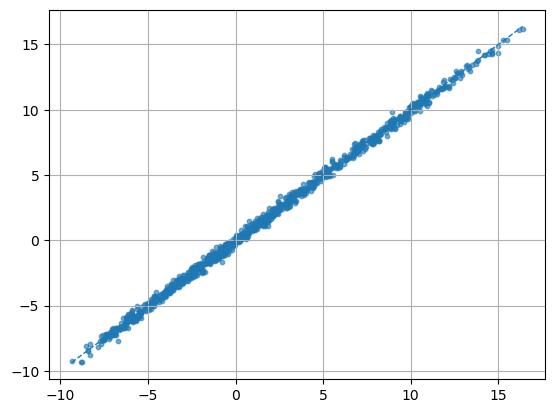

In [4]:
i=1
x_kf = kf_states[:, i]
x_act = act_states[:, i]

plt.scatter(x_kf, x_act, s=10, alpha=0.6)

# Add y=x reference line
vmin = min(np.min(x_kf), np.min(x_act))
vmax = max(np.max(x_kf), np.max(x_act))
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1)
plt.grid(True)
plt.savefig('figs/scatter_plot.png', dpi=600, bbox_inches="tight")
plt.show()